In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/drive')


train_df = pd.read_csv("/drive/MyDrive/train_banking77.csv")
test_df = pd.read_csv("/drive/MyDrive/test_Banking77.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

Mounted at /drive
(10003, 3)
(3080, 3)


,text,label,label_text
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival
3,Can I track my card while it is in the process...,11,card_arrival
4,"How do I know if I will get my card, or if it ...",11,card_arrival


In [2]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        10003 non-null  object
 1   label       10003 non-null  int64 
 2   label_text  10003 non-null  object
dtypes: int64(1), object(2)
memory usage: 234.6+ KB


In [4]:
train_df["label_text"].nunique()

77

In [5]:
train_df["label_text"].value_counts()

,count
label_text,
card_payment_fee_charged,187
direct_debit_payment_not_recognised,182
balance_not_updated_after_cheque_or_cash_deposit,181
wrong_amount_of_cash_received,180
cash_withdrawal_charge,177
...,...
lost_or_stolen_card,82
card_swallowed,61
card_acceptance,59


In [6]:
train_df.groupby("label")["label_text"].nunique()

,label_text
label,
0,1
1,1
2,1
3,1
4,1
...,...
72,1
73,1
74,1


In [7]:
train_df.groupby("label")["label_text"].describe()

,count,unique,top,freq
label,,,,
0,159,1,activate_my_card,159
1,110,1,age_limit,110
2,126,1,apple_pay_or_google_pay,126
3,87,1,atm_support,87
4,127,1,automatic_top_up,127
...,...,...,...,...
72,41,1,virtual_card_not_working,41
73,135,1,visa_or_mastercard,135
74,121,1,why_verify_identity,121


In [8]:
train_df["label_text"].value_counts().head(10)

,count
label_text,
card_payment_fee_charged,187
direct_debit_payment_not_recognised,182
balance_not_updated_after_cheque_or_cash_deposit,181
wrong_amount_of_cash_received,180
cash_withdrawal_charge,177
transaction_charged_twice,175
declined_cash_withdrawal,173
transfer_fee_charged,172
balance_not_updated_after_bank_transfer,171


In [9]:
train_df["label_text"].value_counts().tail(10)

,count
label_text,
get_disposable_virtual_card,97
top_up_limits,97
receiving_money,95
atm_support,87
compromised_card,86
lost_or_stolen_card,82
card_swallowed,61
card_acceptance,59
virtual_card_not_working,41


In [11]:
class_counts = train_df["label_text"].value_counts()

class_counts.describe()

,count
count,77.000000
mean,129.909091
std,32.942207
min,35.000000
25%,112.000000
50%,127.000000
75%,159.000000
max,187.000000


In [12]:
class_counts.max() / class_counts.min()

5.3428571428571425

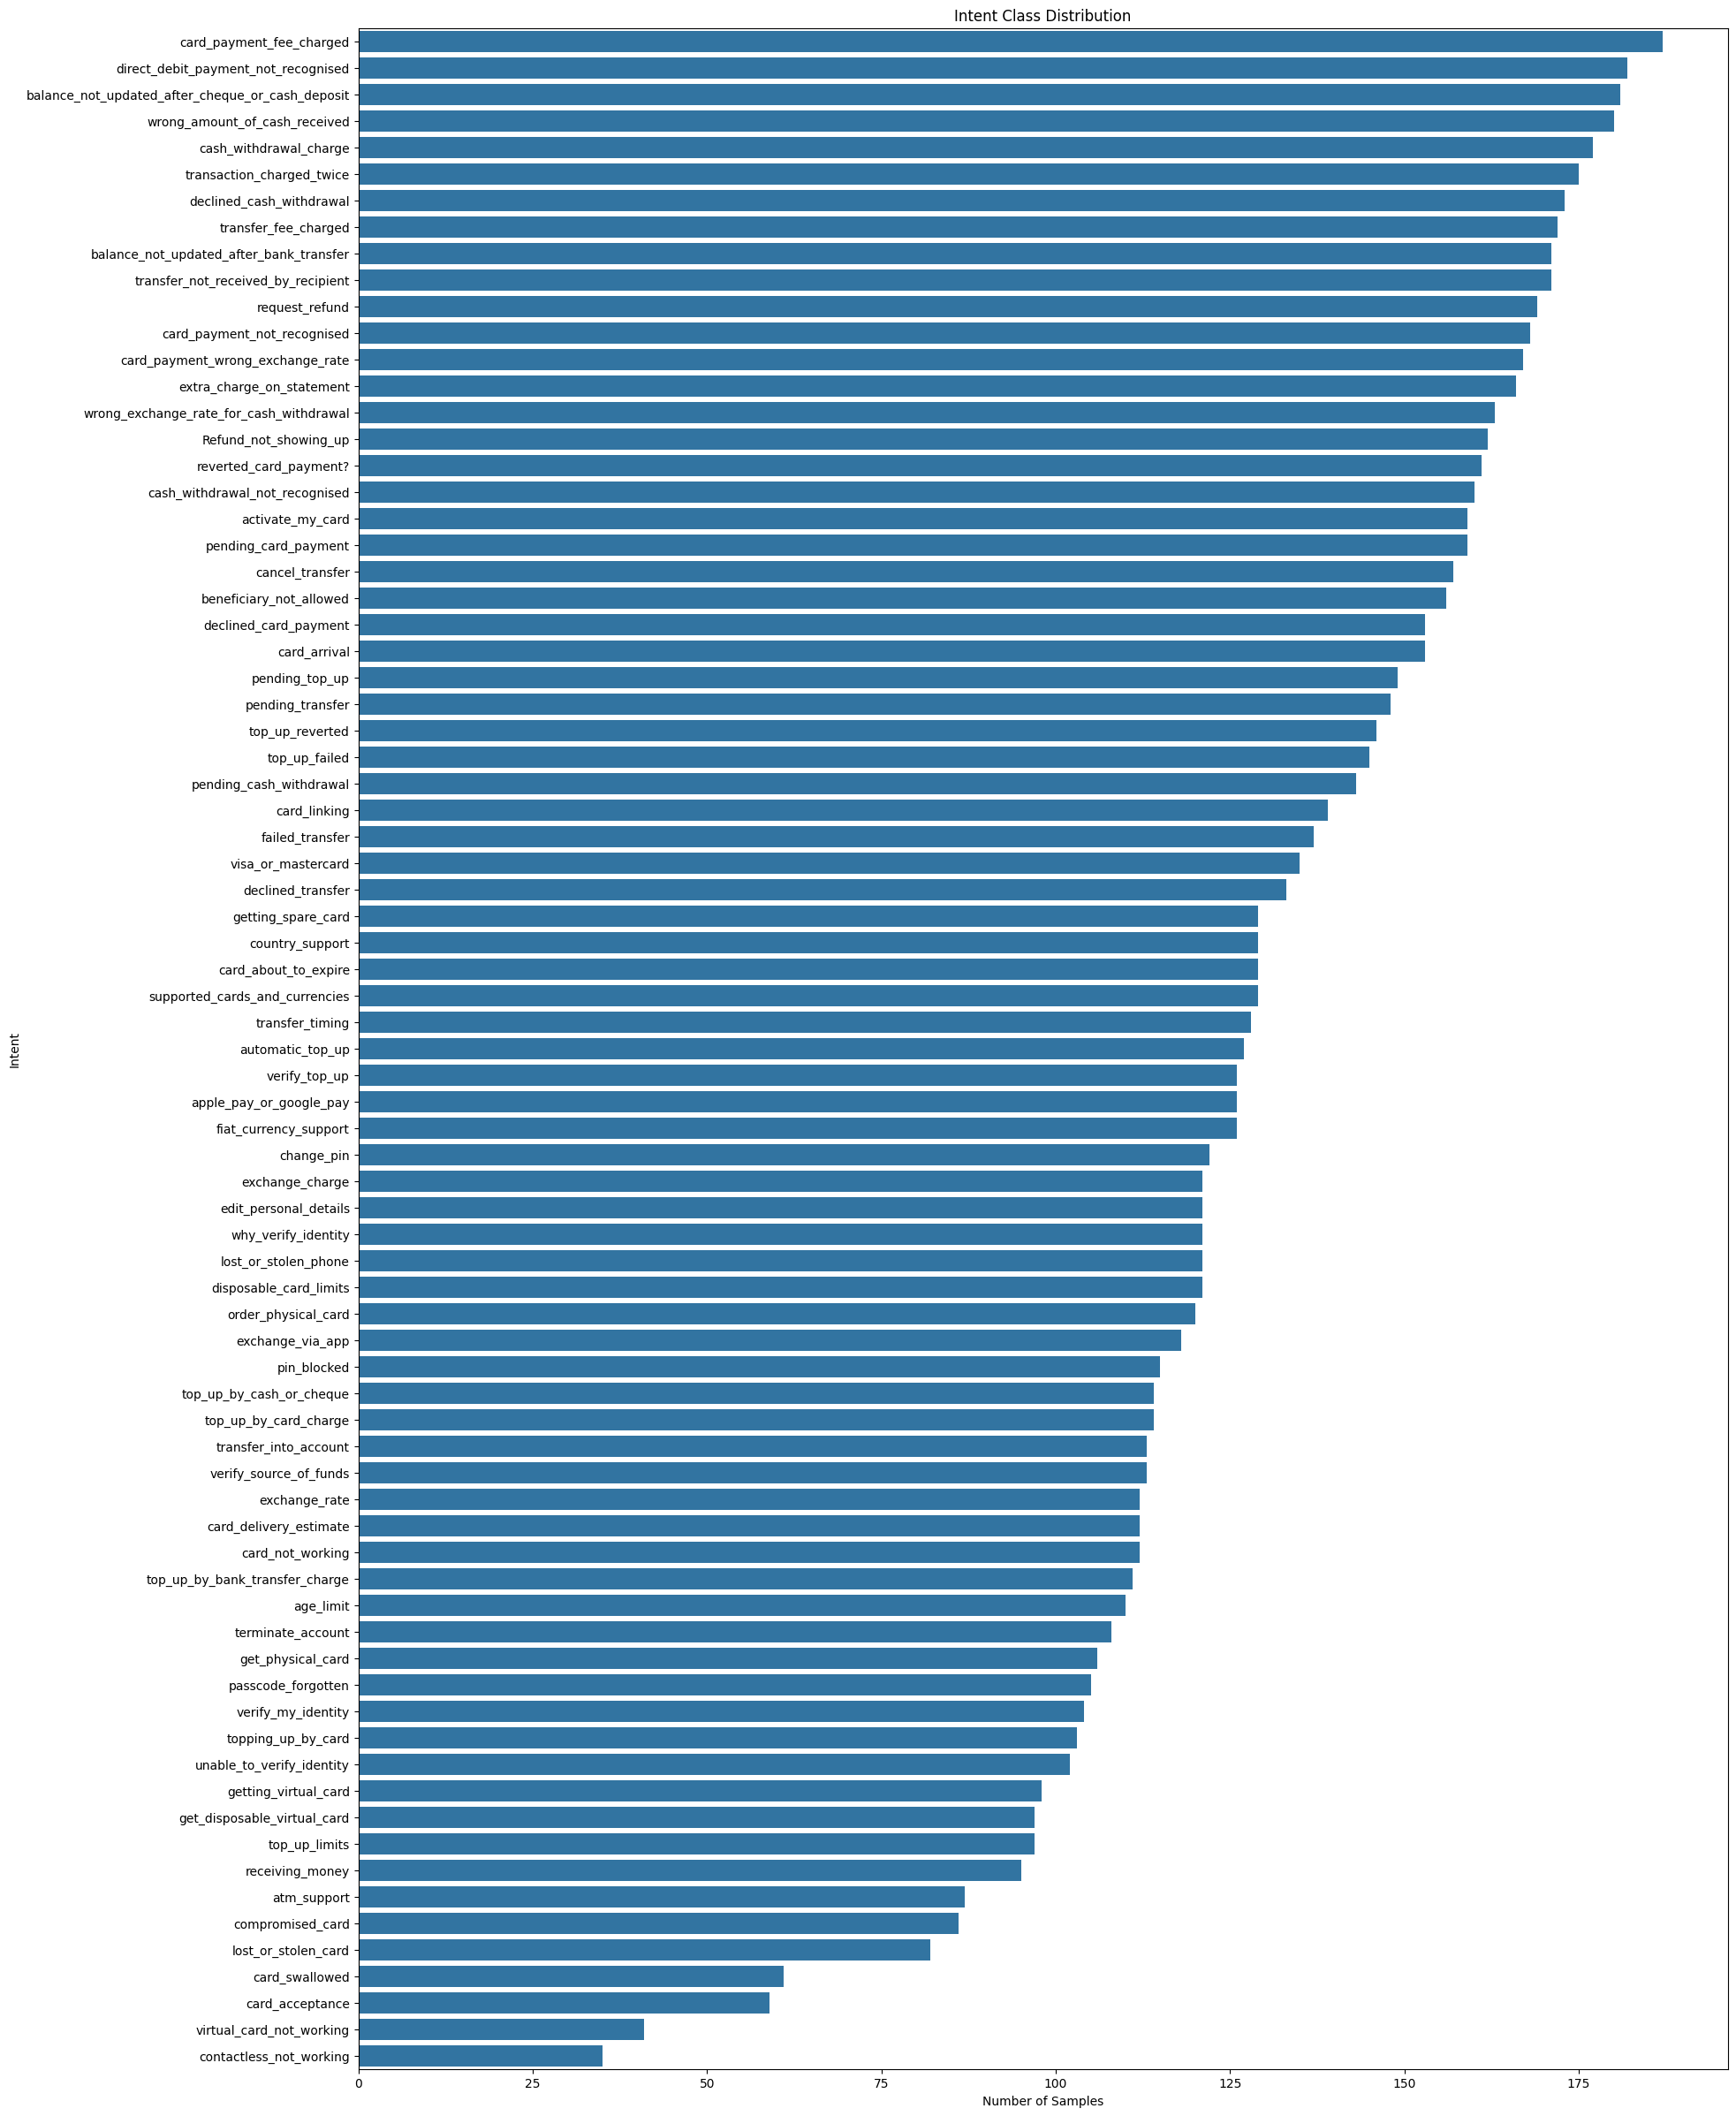

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = train_df["label_text"].value_counts()

plt.figure(figsize=(20, 30))

sns.barplot(
    x=class_counts.values,
    y=class_counts.index
)

plt.title("Intent Class Distribution")
plt.xlabel("Number of Samples")
plt.ylabel("Intent")

plt.show()

In [15]:
train_df["text_length"] = train_df["text"].apply(
    lambda x: len(x.split())
)

train_df["text_length"].describe()

,text_length
count,10003.000000
mean,11.949415
std,7.891577
min,2.000000
25%,7.000000
50%,10.000000
75%,13.000000
max,79.000000


In [16]:
train_df["text_length"].quantile([0.90,0.95,0.99])

,text_length
0.90,22.0
0.95,29.0
0.99,43.0


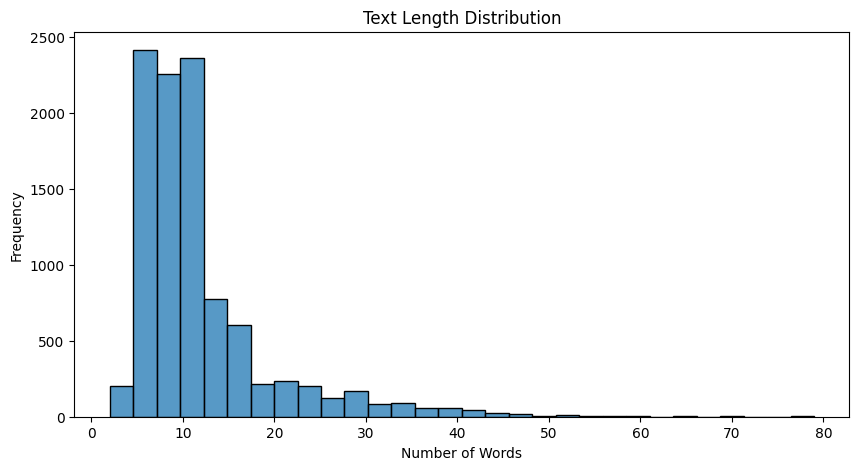

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    train_df["text_length"],
    bins=30
)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [21]:
intent_length = (
    train_df
    .groupby("label_text")["text_length"]
    .mean()
    .sort_values()
)

intent_length.head(10)


,text_length
label_text,
card_acceptance,7.474576
atm_support,7.689655
passcode_forgotten,7.695238
get_physical_card,7.707547
top_up_limits,7.742268
exchange_rate,7.830357
order_physical_card,7.875000
visa_or_mastercard,8.155556
verify_top_up,8.309524


In [22]:
intent_length.tail(10)

,text_length
label_text,
wrong_amount_of_cash_received,15.283333
cash_withdrawal_not_recognised,15.437500
wrong_exchange_rate_for_cash_withdrawal,15.460123
Refund_not_showing_up,15.808642
transaction_charged_twice,15.988571
direct_debit_payment_not_recognised,15.989011
failed_transfer,15.992701
pending_cash_withdrawal,16.531469
transfer_fee_charged,17.395349


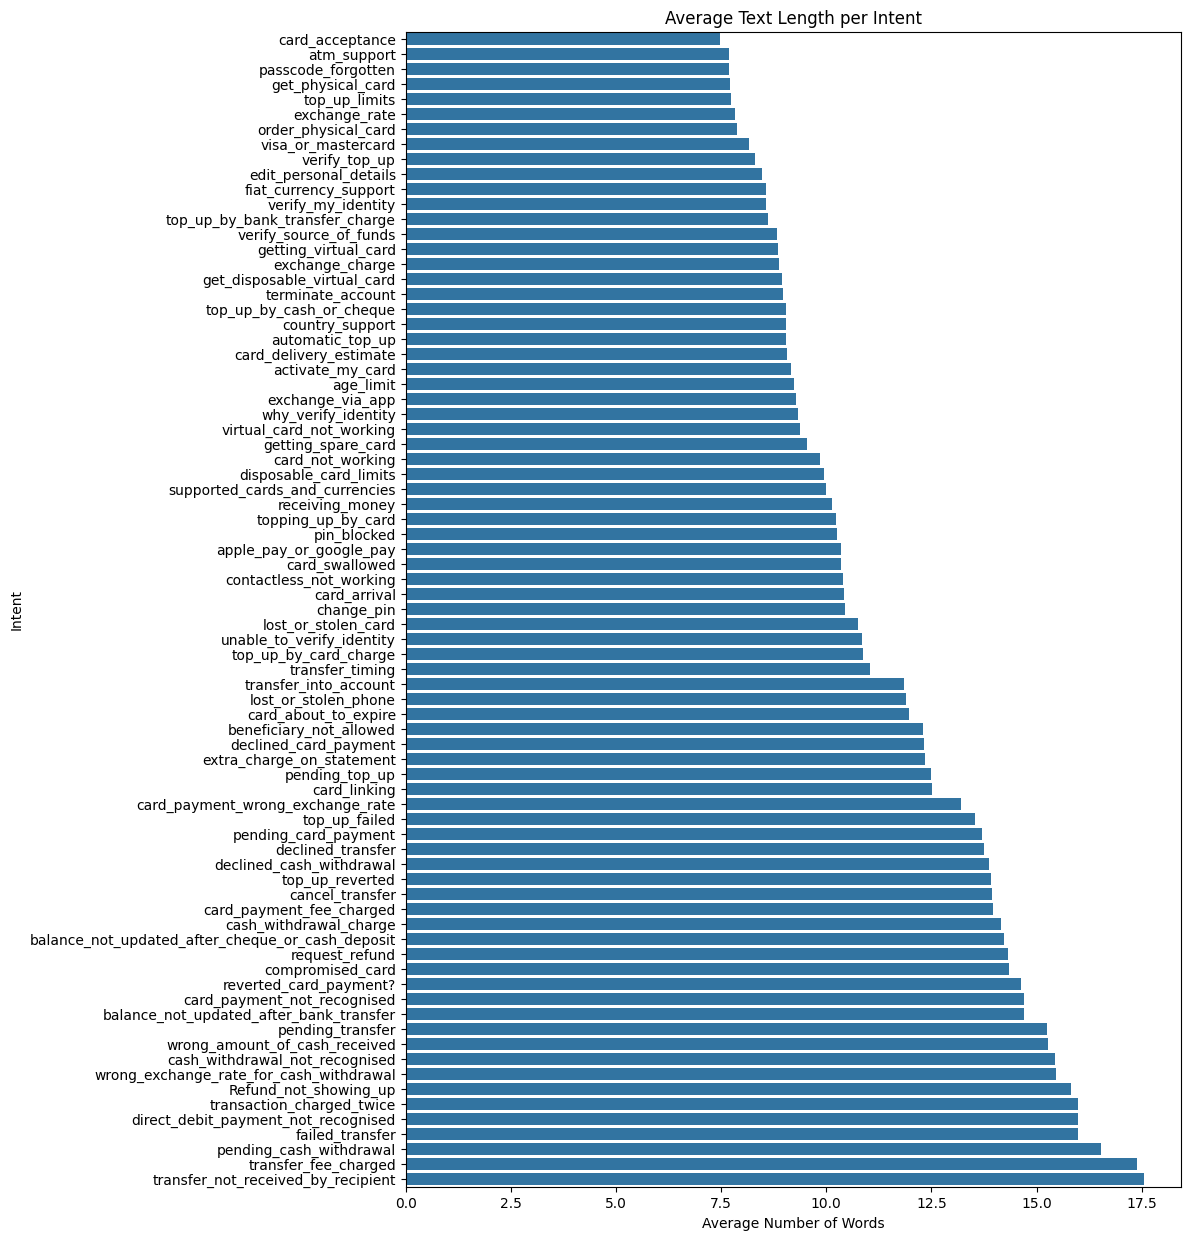

In [23]:
plt.figure(figsize=(10,15))

sns.barplot(
    x=intent_length.values,
    y=intent_length.index
)

plt.title("Average Text Length per Intent")
plt.xlabel("Average Number of Words")
plt.ylabel("Intent")

plt.show()

In [24]:
train_df.groupby("label_text").sample(3)

,text,label,label_text,text_length
5721,I made a purchase a few weeks ago but wasn't h...,51,Refund_not_showing_up,28
5728,"Hello. I bought an item a while ago, and have ...",51,Refund_not_showing_up,35
5738,The refund I asked for isn't showing up,51,Refund_not_showing_up,8
9325,"What are the steps to activate the card, as it...",0,activate_my_card,15
9200,I would like to activate my card.,0,activate_my_card,7
...,...,...,...,...
2408,I didn't receive the correct amount of cash,75,wrong_amount_of_cash_received,8
2485,The amount of cash i have received is not corr...,75,wrong_amount_of_cash_received,10
8315,I tried withdrawing money in another country a...,76,wrong_exchange_rate_for_cash_withdrawal,13
8219,I have made a withdraw from an ATM this last h...,76,wrong_exchange_rate_for_cash_withdrawal,21


In [25]:
sample_intents = train_df["label_text"].sample(5, random_state=42)

train_df[
    train_df["label_text"].isin(sample_intents)
].groupby("label_text").sample(3)

,text,label,label_text,text_length
8777,How long do I have to wait until the transferr...,5,balance_not_updated_after_bank_transfer,13
8723,"Can you tell me how long it would take, to mak...",5,balance_not_updated_after_bank_transfer,26
8646,Is there a longer processing time for internat...,5,balance_not_updated_after_bank_transfer,10
2580,why is there a fee for a payment on my card?,15,card_payment_fee_charged,11
2532,Where can I find out the fee structure for my ...,15,card_payment_fee_charged,32
2672,I was charged an extra fee for a card payment....,15,card_payment_fee_charged,17
6940,Is it possible to change my PIN?,21,change_pin,7
6905,Can I change my PIN without being physically p...,21,change_pin,9
6959,What steps do I have to take to change my PIN?,21,change_pin,11
5940,For some reason my card payment hasn't worked....,25,declined_card_payment,16


In [3]:
train_df.duplicated(subset="text").sum()

np.int64(0)

In [26]:
train_df.groupby("text")["label"].nunique().value_counts()

,count
label,
1,10003
